In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import random

import matplotlib.pyplot as plt

import os
import sys

random.seed(0)
pair_seed = 420

module_path = os.path.abspath(".")
if module_path not in sys.path:
    sys.path.append(module_path)

dtype = torch.float32

############## Use GPU ##############
USE_GPU = True
#####################################
if USE_GPU == True and torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print('using device:', device)

using device: cpu


# Creating the data
We want the input to be a list of pairs which are turned into one-hot encoders. These are all possible combinations of integers. Then we want the output to be the sum mod p. That is just an array of the same length as the number of pairs.

In [ ]:
import copy

def data_create(p: int, frac: float, device, pair_seed: int | None = None):
    X_pairs = torch.cartesian_prod(
        torch.arange(p, device=device),
        torch.arange(p, device=device)
    )
    Y = (X_pairs[:, 0] + X_pairs[:, 1]) % p # making the dataset for addition mod p
    X = F.one_hot(X_pairs, num_classes=p).float() # one-hot encoding the pairs, so each pair is represented as a 2*p dimensional vector

    n = X.shape[0] # total number of pairs, which is p^2
    n_train = int(frac * n) # number of samples we are using to train the model, which is frac * p^2

    if pair_seed is None:
        perm = torch.randperm(n, device=device) # generating a random permutation of the indices from 0 to n-1, which will be used to split the dataset into training and testing sets
    else:
        g = torch.Generator(device=device).manual_seed(pair_seed) # creating a random generator with a specific seed for reproducibility, and then generating the random permutation using this generator
        perm = torch.randperm(n, generator=g, device=device)

    train_idx = perm[:n_train] # selecting the first n_train indices from the permuted indices to be used for training
    test_idx = perm[n_train:]

    return {
        "X_pairs": X_pairs,
        "Y": Y,
        "X_train": X[train_idx],
        "Y_train": Y[train_idx],
        "X_test": X[test_idx],
        "Y_test": Y[test_idx],
        "pairs_train": X_pairs[train_idx],
        "pairs_test": X_pairs[test_idx],
    }


def noisy_data_create(p: int, frac: float, noise_level:float, device, pair_seed: int | None = None, fixed_seed:bool=True):
    X_pairs = torch.cartesian_prod(
    torch.arange(p, device=device),
    torch.arange(p, device=device)
    )
    Y = (X_pairs[:, 0] + X_pairs[:, 1]) % p # making the dataset for addition mod p
    X = F.one_hot(X_pairs, num_classes=p).float() # one-hot encoding the pairs, so each pair is represented as a 2*p dimensional vector

    n = X.shape[0] # total number of pairs, which is p^2
    # print(f'total number of samples = {n}, p^2 = {p**2}')
    n_train = int(frac * n) # number of samples we are using to train the model, which is frac * p^2
    # print(f'number of training samples = {n_train}, frac * p^2 = {frac * p**2}')

    if pair_seed is None:
        perm = torch.randperm(n, device=device) # generating a random permutation of the indices from 0 to n-1, which will be used to split the dataset into training and testing sets
    else:
        g = torch.Generator(device=device).manual_seed(pair_seed) # creating a random generator with a specific seed for reproducibility, and then generating the random permutation using this generator
        perm = torch.randperm(n, generator=g, device=device)

    train_idx = perm[:n_train] # selecting the first n_train indices from the permuted indices to be used for training
    # print(f'unique labels in the clean training set = {torch.unique(Y[train_idx])}')
    # print(f'number of labels in the clean training set = {len(Y[train_idx])}')
    test_idx = perm[n_train:]

    noisy_set_size = int(noise_level * frac * p**2) # number of samples we are going to corrupt with noise
    # print(f'number of noisy samples = {noisy_set_size}')

    training_set_pre_corruption = Y[train_idx] # the clean labels for the training set before corruption
    # print(f'number of labels in the clean training set = {len(training_set_pre_corruption)}')

    noisy_Y = training_set_pre_corruption.clone() # start with a copy of the clean labels
    
    if fixed_seed:
        torch.manual_seed(0) # setting the random seed to 0 for reproducibility
    
    noise_indices = torch.randperm(noisy_Y.shape[0], device=device)[:noisy_set_size] # randomly select which samples to corrupt
    
    random_labels = torch.randint(0, p, (noisy_set_size,), device=device) # generate random labels for the corrupted samples
    
    noisy_Y[noise_indices] = random_labels # replace the selected labels with random ones

    return {
        "X_pairs": X_pairs,
        "Y": Y,
        "X_train": X[train_idx],
        "Y_train": noisy_Y,
        "X_test": X[test_idx],
        "Y_test": Y[test_idx],
        "pairs_train": X_pairs[train_idx],
        "pairs_test": X_pairs[test_idx],
    }

noisy_data_create(p=97, frac=0.5, noise_level=0.1, device=device, pair_seed=pair_seed, fixed_seed=True)


# Doshi's function - more flexible
# def noisy_dataset(p:int, pair_seed:int, frac:float, noise_level:float, device, dtype, operation='addition', fixed_seed:bool=True):
    
#     if operation.lower() not in ['addition', 'multiplication']:
#         raise Exception('noisy_dataset function only makes Modular Addition and Multipllication datasets.')
    
#     pairs = [(i,j) for i in range(p) for j in range(p)]
#     X_og = torch.tensor(pairs)
#     if operation.lower() == 'addition': Y_og = (( X_og[:,0]**1 + X_og[:,1]**1 )**1) % p
#     elif operation.lower() == 'multiplication': Y_og = (( X_og[:,0]**1 * X_og[:,1]**1 )**1) % p
#     X_og = F.one_hot(X_og, num_classes=p)
    
#     #### Deterministic shuffle
#     random.seed(pair_seed)
#     orderlist = list(range(len(pairs)))
#     random.shuffle(orderlist)
#     pairs = [pairs[i] for i in orderlist]
    
#     X = torch.tensor(pairs)
    
#     if operation.lower() == 'addition': Y = (( X[:,0]**1 + X[:,1]**1 )**1) % p
#     elif operation.lower() == 'multiplication': Y = (( X[:,0]**1 * X[:,1]**1 )**1) % p
#     X = F.one_hot(X, num_classes=p)
#     total_size = Y.shape[0]
#     train_size = int(frac * total_size)
#     test_size = total_size - train_size

#     n_noise = int(noise_level * train_size)
#     ids = torch.arange(n_noise)

#     if fixed_seed == True:
#         torch.random.manual_seed(0)
#         random_labels = torch.randint(0, p, (n_noise,))
#         labels_noise = copy.deepcopy(Y)
#         labels_noise[:n_noise] = random_labels
#     else:
#         random_labels = torch.randint(0, p, (n_noise,))
#         labels_noise = copy.deepcopy(Y)
#         print(labels_noise.shape, random_labels.shape)
#         # labels_noise[torch.randperm(train_size)[:n_noise]] = random_labels
#         labels_noise[:n_noise] = copy.deepcopy(random_labels)
#         # count = 0
#         # for i in range(n_noise):
#         #     if random_labels[i] == Y[i]:
#         #         count += 1
#         #         labels_noise[i] = torch.randint(0, p, (1,)).item()
#         # print(f'# of changed corrupted labels = {count}')
        
#     Y_noisy = copy.deepcopy(Y_og)
#     for i in range(total_size):
#         Y_noisy[orderlist[i]] = labels_noise[i]
#     Y_noisy = Y_noisy.to(device=device, dtype=torch.long)
       
#     X_og = X_og.to(device=device, dtype=dtype)
#     Y_og = Y_og.to(device=device, dtype=torch.long)
#     X_train = X[:train_size].to(device=device, dtype=dtype)
#     Y_train = labels_noise[:train_size].to(device=device, dtype=torch.long)
#     X_test = X[train_size:].to(device=device, dtype=dtype)
#     Y_test = labels_noise[train_size:].to(device=device, dtype=torch.long)
    
#     dataset_dict = {
#         'X_train': X_train, 'Y_train': Y_train, 'X_test': X_test, 'Y_test': Y_test,
#         'X_og': X_og, 'Y_og': Y_og, 'Y_noisy': Y_noisy, 'orderlist': orderlist,
#         'p': p, 'data_frac': frac, 'noise_level': noise_level
#     }
    
#     return dataset_dict


In [15]:
# dat=data_create(97, 0.3, device, pair_seed)
# print(dat['Y'].shape)
# print(dat['X_train'].shape)

# ndat = noisy_dataset(p, pair_seed, frac, noise_level, device, dtype, operation='addition', fixed_seed=True)
# print(ndat['Y_og'].shape)

ndat=noisy_data_create(97, 0.3, 0.1, device, pair_seed, fixed_seed=True)
print(ndat['Y'].shape)

print(ndat['X_train'].shape)

torch.Size([9409])
torch.Size([2822, 2, 97])


# MLP class definition
Below I just define a class that has a 2-layer MLP and performs the required forward pass

In [16]:
class MLP(nn.Module):
    def __init__(self, in_size, hid_size, out_size):
        super(MLP, self).__init__()

        self.in_size=in_size
        self.hid_size=hid_size
        self.out_size=out_size
        self.fc1=nn.Linear(in_size, hid_size, bias=False)
        self.fc2=nn.Linear(hid_size, out_size, bias=False)
        
        torch.nn.init.normal_(self.fc1.weight, mean=0.0, std=0.25**0.5 / np.power(2*self.hid_size, 1/3)) #### standard initialization
        torch.nn.init.normal_(self.fc2.weight, mean=0.0, std=0.25**0.5 / np.power(2*self.hid_size, 1/3))

    def forward(self, x):
        x = x.flatten(1)
        x = self.fc2( F.relu(  self.fc1(x)  ) )
        return x


# Define loss function and criterion

In [19]:
p = 97
frac = 0.5
noise_level = 0.1
hid_size = 512
n_epochs = 30000

torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

data = noisy_dataset(p, pair_seed, frac, noise_level, device, dtype, operation='addition', fixed_seed=True)
# noisy_data_create(p, frac, noise_level, device, pair_seed=420, fixed_seed=True)

model = MLP(in_size=2*p, hid_size=hid_size, out_size=p).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-2, weight_decay=5) #changed from 1e-3 and 0.5 to match Doshi


In [20]:
train_losses = torch.empty(n_epochs, device=device)
test_losses = torch.empty(n_epochs, device=device)
train_accs = torch.empty(n_epochs, device=device)
test_accs = torch.empty(n_epochs, device=device)

data=noisy_data_create(p, frac, noise_level, device, pair_seed=420, fixed_seed=True)
X_train=data['X_train'].float()
Y_train=data['Y_train']
X_test=data['X_test'].float()
Y_test=data['Y_test']

for epoch in range(n_epochs):
    model.train()

    optimizer.zero_grad()
    logits = model(X_train)
    loss = criterion(logits, Y_train)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        train_logits = model(X_train)
        test_logits = model(X_test)

        train_loss = criterion(train_logits, Y_train)
        test_loss = criterion(test_logits, Y_test)

        train_pred = train_logits.argmax(dim=1)
        test_pred = test_logits.argmax(dim=1)

        train_acc = (train_pred == Y_train).float().mean()
        test_acc = (test_pred == Y_test).float().mean()

    train_losses[epoch] = train_loss
    test_losses[epoch] = test_loss
    train_accs[epoch] = train_acc
    test_accs[epoch] = test_acc

    if (epoch + 1) % 500 == 0:
        print(
            f"Epoch {epoch+1:6d}/{n_epochs} | "
            f"train_loss={train_loss.item():.6f} | "
            f"test_loss={test_loss.item():.6f} | "
            f"train_acc={train_acc.item():.6f} | "
            f"test_acc={test_acc.item():.6f}"
        )

Epoch    500/30000 | train_loss=0.609582 | test_loss=1.902773 | train_acc=0.996599 | test_acc=0.929649
Epoch   1000/30000 | train_loss=0.573823 | test_loss=1.507991 | train_acc=0.985332 | test_acc=0.988735
Epoch   1500/30000 | train_loss=0.570815 | test_loss=1.413618 | train_acc=0.978741 | test_acc=0.995962
Epoch   2000/30000 | train_loss=0.555175 | test_loss=1.345621 | train_acc=0.980230 | test_acc=0.995749
Epoch   2500/30000 | train_loss=0.542550 | test_loss=1.302150 | train_acc=0.980867 | test_acc=0.997024
Epoch   3000/30000 | train_loss=0.540914 | test_loss=1.270123 | train_acc=0.978529 | test_acc=0.998087
Epoch   3500/30000 | train_loss=0.534650 | test_loss=1.273537 | train_acc=0.976828 | test_acc=0.998087
Epoch   4000/30000 | train_loss=0.525278 | test_loss=1.254953 | train_acc=0.978954 | test_acc=0.997662
Epoch   4500/30000 | train_loss=0.522629 | test_loss=1.255568 | train_acc=0.981080 | test_acc=0.997024
Epoch   5000/30000 | train_loss=0.517442 | test_loss=1.240510 | train_acc

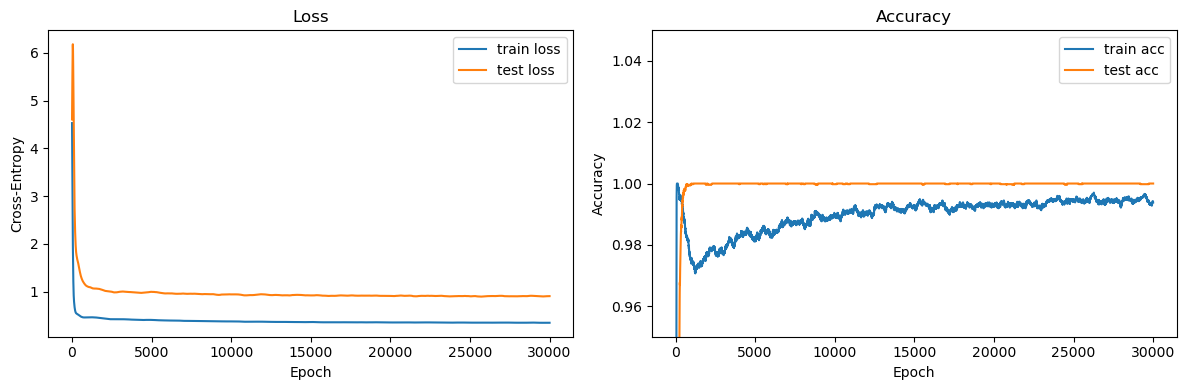

In [64]:
epochs_cpu = torch.arange(len(train_losses)).cpu()
train_losses_cpu = train_losses.detach().cpu()
test_losses_cpu = test_losses.detach().cpu()
train_accs_cpu = train_accs.detach().cpu()
test_accs_cpu = test_accs.detach().cpu()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_cpu, train_losses_cpu, label="train loss")
axes[0].plot(epochs_cpu, test_losses_cpu, label="test loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy")
axes[0].legend()

axes[1].plot(epochs_cpu, train_accs_cpu, label="train acc")
axes[1].plot(epochs_cpu, test_accs_cpu, label="test acc")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim([0.95, 1.05])
axes[1].legend()

plt.tight_layout()
plt.show()


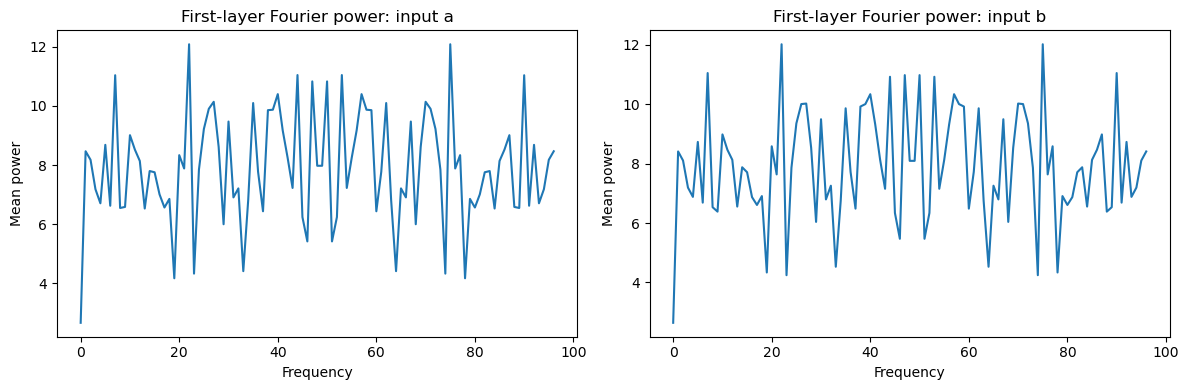

In [8]:
W1 = model.fc1.weight.detach().cpu()          # shape: (hid_size, 2*p)
Wa = W1[:, :p]                                # weights on first input
Wb = W1[:, p:]                                # weights on second input

Fa = torch.fft.fft(Wa, dim=1)                 # shape: (hid_size, p)
Fb = torch.fft.fft(Wb, dim=1)

power_a = (Fa.abs() ** 2).mean(dim=0)
power_b = (Fb.abs() ** 2).mean(dim=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(power_a.numpy())
axes[0].set_title("First-layer Fourier power: input a")
axes[0].set_xlabel("Frequency")
axes[0].set_ylabel("Mean power")

axes[1].plot(power_b.numpy())
axes[1].set_title("First-layer Fourier power: input b")
axes[1].set_xlabel("Frequency")
axes[1].set_ylabel("Mean power")

plt.tight_layout()
plt.show()


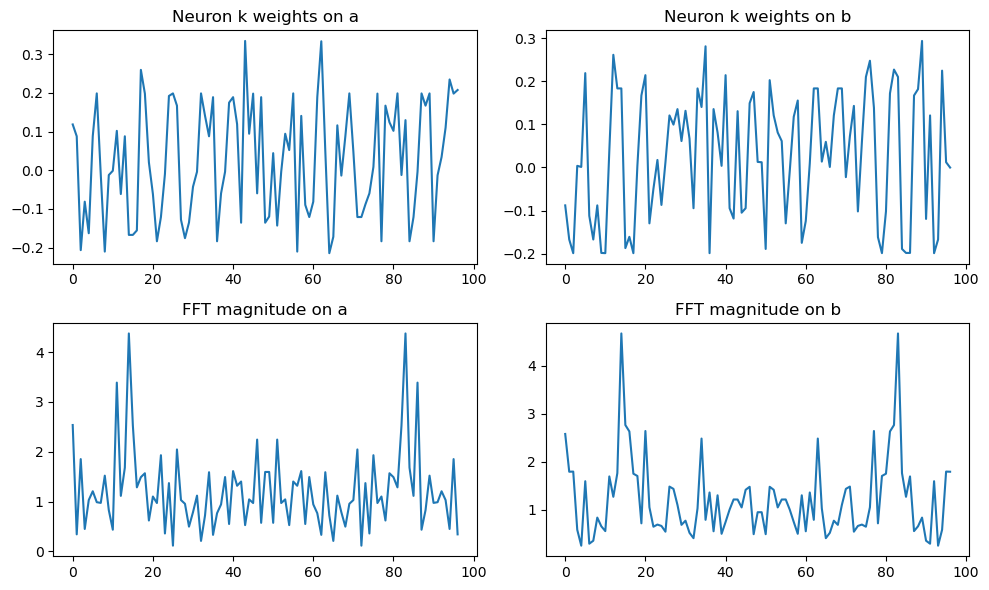

In [9]:
k = 33

fig, axes = plt.subplots(2, 2, figsize=(10, 6))

axes[0, 0].plot(Wa[k].numpy())
axes[0, 0].set_title("Neuron k weights on a")

axes[0, 1].plot(Wb[k].numpy())
axes[0, 1].set_title("Neuron k weights on b")

axes[1, 0].plot(Fa[k].abs().numpy())
axes[1, 0].set_title("FFT magnitude on a")

axes[1, 1].plot(Fb[k].abs().numpy())
axes[1, 1].set_title("FFT magnitude on b")

plt.tight_layout()
plt.show()


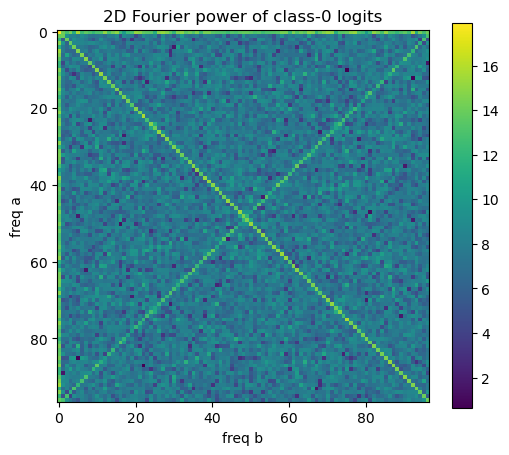

In [10]:
with torch.no_grad():
    X_pairs = torch.cartesian_prod(torch.arange(p, device=device), torch.arange(p, device=device))
    X_full = F.one_hot(X_pairs, num_classes=p).float()
    logits = model(X_full).cpu()              # shape: (p*p, p)

logit_c = logits[:, 0].reshape(p, p)          # class-0 logit over the grid
F2 = torch.fft.fft2(logit_c)
power2 = (F2.abs() ** 2)

plt.figure(figsize=(6, 5))
plt.imshow(torch.log1p(power2).numpy(), cmap="viridis")
plt.colorbar()
plt.title("2D Fourier power of class-0 logits")
plt.xlabel("freq b")
plt.ylabel("freq a")
plt.show()


# To do $S_5$ we need:
* a function that generates the permutations
* a function that computes the multiplication
* mlp with 1 hidden layer and two embeddings

In [11]:
from sympy.combinatorics.named_groups import SymmetricGroup as SymPySymmetricGroup
from sympy.combinatorics import Permutation, PermutationGroup
import math

class symmgr():
    def __init__(self, n:int, device):
        self.g=SymPySymmetricGroup(n)
        self.n = n
        
        self.device=device
        self.elements = list(self.g.generate_schreier_sims())
        self.order = len(self.elements)
        self.multiplication_table = self.compute_multiplication_table()
        #elements in g are stored in ._elements; elements is an array of n! indices, each index labelling one permutation, which is an n-array
        #when we embed later in the MLP, we will embed indices, not permutations themselves. 
        #multiplication table takes 2 indices 


        self.identity = [i for i in range(self.order) if self.idx_to_perm(i).order() == 1][0] #compute the index of the identity, which might not be 0

    def idx_to_perm(self, x):
        #convert index of a permutation to the array
        return self.elements[x]
    
    def perm_to_idx(self,perm):
        #convert perm to the index
        return self.elements.index(perm)
    
    def compute_signatures(self, x):
        #given an index 'x', compute the signature of that permutation having index x
        return self.idx_to_perm(x).signature()
    
    def compute_inverses(self, x):
        #given an index 'x', compute the index of the inverse permutation
        return (self.multiplication_table[x, :] == self.identity).nonzero().item()
    
    def compose(self, x, y):
        #take two indices and return the index of the permutation which lies in the composition
        return self.perm_to_idx(self.idx_to_perm(x) * self.idx_to_perm(y))
    

    def compute_multiplication_table(self):
        #this gives for (i,j) indices the index of the composed permutation
        table = torch.zeros((self.order, self.order), dtype=torch.int64, device=self.device)
        for i in range(self.order):
            for j in range(self.order):
                table[i, j] = self.compose(i, j)
        return table
    

In [12]:
# I want my data to be embedded as ((n!)^2,2) and ((n!)^2) vectors
def data_create_sym(n: int, frac: float, device, pair_seed: int | None = None):
    grp=symmgr(n, device)
    
    idx=torch.arange(grp.order,device=device)
    X=torch.cartesian_prod(idx,idx)
    Y = torch.tensor([grp.compose(i.item(), j.item()) for i, j in X],device=device)



    if pair_seed is None:
        perm = torch.randperm(grp.order*grp.order, device=device)
    else:
        g = torch.Generator(device=device).manual_seed(pair_seed)
        perm = torch.randperm(grp.order*grp.order, generator=g, device=device)

    N=X.shape[0]
    N_train=int(frac*N)

    train_idx=perm[:N_train]
    test_idx=perm[N_train:]

    return {'X': X[perm], 'Y': Y[perm], 'X_train': X[train_idx], 'Y_train': Y[train_idx], 'X_test': X[test_idx], 'Y_test': Y[test_idx], 'grp':grp}   
    

The order of the permutations is reversed. If $p(i)$ is the first row and $q(i)$ is the second, the multiplication is $q(p(i))$

In [13]:
dic=data_create_sym(3, 0.3, device, pair_seed)
print(dic['X'][9])
print(dic['Y'][9])
print(dic['grp'].idx_to_perm(dic['X'][9,0].item()).array_form)
print(dic['grp'].idx_to_perm(dic['X'][9,1].item()).array_form)
print(dic['grp'].idx_to_perm(dic['Y'][9].item()).array_form)

tensor([5, 4])
tensor(2)
[2, 1, 0]
[1, 0, 2]
[2, 0, 1]


In [14]:
class PermMLP(nn.Module):
    def __init__(self, in_size, embed_size, hid_size, out_size):
        super(PermMLP,self).__init__()

        self.in_size=in_size
        self.out_size=out_size
        self.hid_size=hid_size
        self.embed_size=embed_size

        self.El=nn.Embedding(in_size, embed_size)
        self.W=nn.Linear(2*embed_size,hid_size, bias=False)

        self.Er=nn.Embedding(in_size, embed_size)
        

        self.U=nn.Linear(hid_size,out_size,bias=False)
        
        nn.init.xavier_normal_(self.El.weight)
        nn.init.xavier_normal_(self.W.weight)

        nn.init.xavier_normal_(self.Er.weight)
      

        nn.init.xavier_normal_(self.U.weight)

    def forward(self, xl, xr):
        w=torch.cat([self.El(xl), self.Er(xr)], dim=1)
        w=self.U(F.relu(self.W(w)))
        return w
        

In [15]:
n=5
frac = 0.3
hid_size = 128
embed_size=256
in_size=math.factorial(n)
out_size=in_size
n_epochs = 30000

torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

data = data_create_sym(n, frac, device, pair_seed)

modelPerm = PermMLP(in_size=in_size, embed_size=embed_size, hid_size=hid_size, out_size=out_size).to(device)
criterion2 = nn.CrossEntropyLoss()
optimizer2 = optim.AdamW(modelPerm.parameters(), lr=1e-3, weight_decay=1) #large weight decay is crucial as the grok time is inverse proportional to it and otherwise we would not see it


In [16]:
train_losses2 = torch.empty(n_epochs, device=device)
test_losses2 = torch.empty(n_epochs, device=device)
train_accs2 = torch.empty(n_epochs, device=device)
test_accs2 = torch.empty(n_epochs, device=device)


Xl_train=data['X_train'][:,0].long()
Xr_train=data['X_train'][:,1].long()
Y_train=data['Y_train'].long()
Xl_test=data['X_test'][:,0].long()
Xr_test=data['X_test'][:,1].long()
Y_test=data['Y_test'].long()

for epoch in range(n_epochs):
    modelPerm.train()

    optimizer2.zero_grad()
    logits = modelPerm(Xl_train, Xr_train)
    loss = criterion2(logits, Y_train)
    loss.backward()
    optimizer2.step()

    modelPerm.eval()
    with torch.no_grad():
        train_logits = modelPerm(Xl_train,Xr_train)
        test_logits = modelPerm(Xl_test,Xr_test)

        train_loss = criterion2(train_logits, Y_train)
        test_loss = criterion2(test_logits, Y_test)

        train_pred = train_logits.argmax(dim=1)
        test_pred = test_logits.argmax(dim=1)

        train_acc = (train_pred == Y_train).float().mean()
        test_acc = (test_pred == Y_test).float().mean()

    train_losses2[epoch] = train_loss
    test_losses2[epoch] = test_loss
    train_accs2[epoch] = train_acc
    test_accs2[epoch] = test_acc

    if (epoch + 1) % 500 == 0:
        print(
            f"Epoch {epoch+1:6d}/{n_epochs} | "
            f"train_loss={train_loss.item():.6f} | "
            f"test_loss={test_loss.item():.6f} | "
            f"train_acc={train_acc.item():.6f} | "
            f"test_acc={test_acc.item():.8f}"
        )

Epoch    500/30000 | train_loss=0.081047 | test_loss=15.616664 | train_acc=1.000000 | test_acc=0.00039683
Epoch   1000/30000 | train_loss=0.041147 | test_loss=15.562391 | train_acc=1.000000 | test_acc=0.00049603
Epoch   1500/30000 | train_loss=0.026009 | test_loss=15.699222 | train_acc=1.000000 | test_acc=0.00039683
Epoch   2000/30000 | train_loss=0.017865 | test_loss=15.931067 | train_acc=1.000000 | test_acc=0.00000000
Epoch   2500/30000 | train_loss=0.012880 | test_loss=16.172403 | train_acc=1.000000 | test_acc=0.00029762
Epoch   3000/30000 | train_loss=0.009582 | test_loss=16.418118 | train_acc=1.000000 | test_acc=0.00019841
Epoch   3500/30000 | train_loss=0.007286 | test_loss=16.662516 | train_acc=1.000000 | test_acc=0.00019841
Epoch   4000/30000 | train_loss=0.005611 | test_loss=16.916510 | train_acc=1.000000 | test_acc=0.00019841
Epoch   4500/30000 | train_loss=0.004370 | test_loss=17.165243 | train_acc=1.000000 | test_acc=0.00039683
Epoch   5000/30000 | train_loss=0.003424 | tes

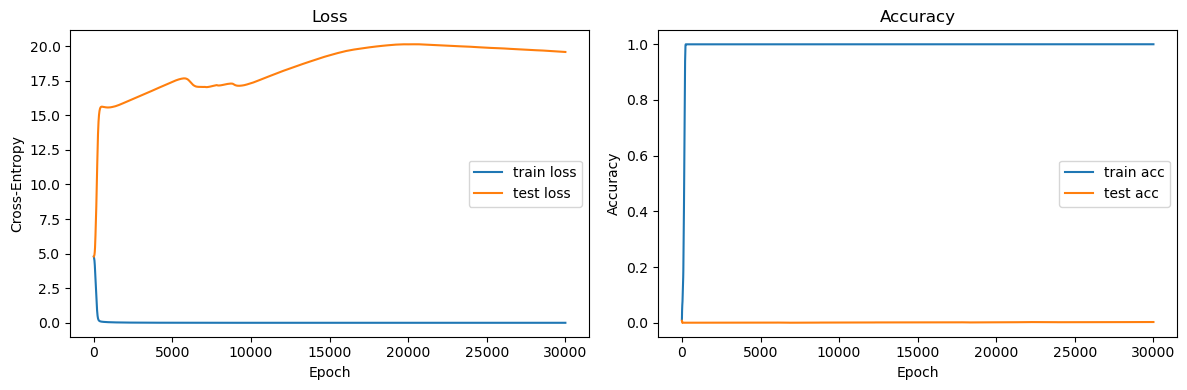

In [17]:
epochs_cpu2 = torch.arange(len(train_losses2)).cpu()
train_losses_cpu2 = train_losses2.detach().cpu()
test_losses_cpu2 = test_losses2.detach().cpu()
train_accs_cpu2 = train_accs2.detach().cpu()
test_accs_cpu2 = test_accs2.detach().cpu()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_cpu2, train_losses_cpu2, label="train loss")
axes[0].plot(epochs_cpu2, test_losses_cpu2, label="test loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy")
axes[0].legend()

axes[1].plot(epochs_cpu2, train_accs_cpu2, label="train acc")
axes[1].plot(epochs_cpu2, test_accs_cpu2, label="test acc")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()
